# K-Means klasteriranje notebook radni

## Importi

In [1]:
import sqlite3
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os, warnings #za ona upozorenja

os.environ["LOKY_MAX_CPU_COUNT"] = "6"
warnings.filterwarnings("ignore")

## Spajanje s bazom

In [2]:
DB_PATH = r"D:\FOI\3. godina\ZAVRSNI\baza_local\glazba.db"

conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT id, title, artist, tempo, energy, valence, 
           danceability, acousticness, instrumentalness
    FROM songs
""", conn)

conn.close()

In [3]:
#provjera jel radi sve ok
print(f"Učitano {len(df)} pjesama")
print(df.head())

Učitano 38 pjesama
   id                       title                artist    tempo  energy  \
0   1               No Broke Boys   Disco Lines;Tinashe  130.999   0.834   
1   2     The Days - NOTION Remix       Chrystal;NOTION  137.812   0.843   
2   3  Black Out Days (Stay Away)  Ian Asher;Phantogram  154.949   0.759   
3   4              Still Into You          CYRIL;maryjo  128.066   0.571   
4   5                         3am               Łaszewo  139.978   0.890   

   valence  danceability  acousticness  instrumentalness  
0    0.962         0.767        0.3400          0.111000  
1    0.237         0.620        0.0062          0.000005  
2    0.127         0.585        0.0177          0.857000  
3    0.681         0.955        0.0147          0.000010  
4    0.651         0.721        0.2200          0.001280  


## Normalizacija parametara sa spotifya

In [4]:
#parametri koji se koriste za klasteriranje
FEATURES = ['tempo', 'energy', 'valence', 'danceability', 'acousticness', 'instrumentalness']

X = df[FEATURES].values

#normalizacija - StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#provjera
print("Originalni tempo (prve 3 pjesme):", X[:3, 0])
print("Skalirani tempo (prve 3 pjesme):", X_scaled[:3, 0])

Originalni tempo (prve 3 pjesme): [130.999 137.812 154.949]
Skalirani tempo (prve 3 pjesme): [0.26354618 0.60924298 1.4787874 ]


## Elbow metoda za odabir opt klastera

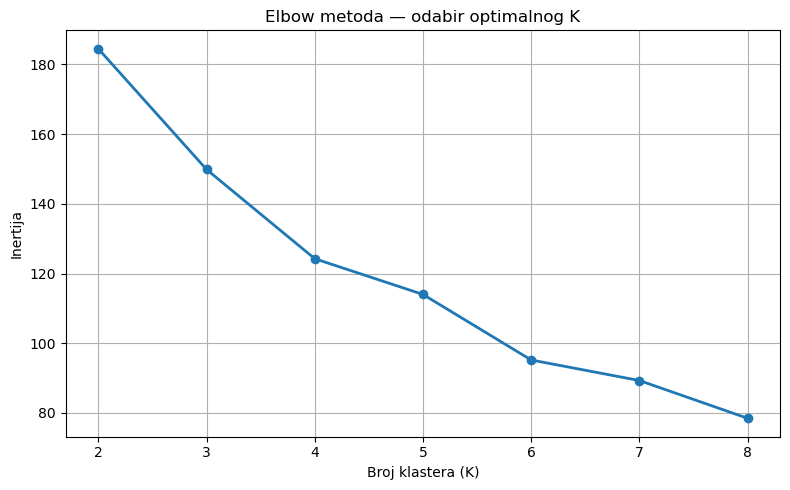

In [6]:
#nema smisla bas radit al za dokumentaciju i teorijski dio mozda jer i tak sam racuno na k=3 zpog 3 "brzine" sporo,srednje,brzo

inertije = []
K_raspon = range(2, 9)  #od kud do kud se testira broj klastera

for k in K_raspon:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertije.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_raspon, inertije, marker='o', linewidth=2)
plt.xlabel("Broj klastera (K)")
plt.ylabel("Inertija")
plt.title("Elbow metoda — odabir optimalnog K")
plt.xticks(K_raspon)
plt.grid(True)
plt.tight_layout()
plt.show()

## Silhouette skor

In [7]:
from sklearn.metrics import silhouette_score

#K-Means s k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_scaled)

#silhouette skor
score = silhouette_score(X_scaled, km.labels_)
print(f"Silhouette Score (K=3): {score:.3f}")

#svaka pjesma koji klaster
df['cluster'] = km.labels_
print("\nRaspodjela pjesama po klasterima:")
print(df['cluster'].value_counts().sort_index())

Silhouette Score (K=3): 0.188

Raspodjela pjesama po klasterima:
cluster
0    17
1    12
2     9
Name: count, dtype: int64


## Centroidi

In [8]:
#originalno (neskalirano)
centroidi = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=FEATURES
)
centroidi.index.name = 'klaster'
print(centroidi.round(3))

           tempo  energy  valence  danceability  acousticness  \
klaster                                                         
0        137.557   0.889    0.249         0.633         0.018   
1        128.665   0.825    0.554         0.753         0.105   
2         99.793   0.717    0.324         0.586         0.071   

         instrumentalness  
klaster                    
0                   0.599  
1                   0.216  
2                   0.561  


## Upis klastera u bazu

In [9]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        UPDATE songs SET cluster = ? WHERE id = ?
    """, (int(row['cluster']), int(row['id'])))

conn.commit()
conn.close()

print("Klasteri upisani u bazu.")

Klasteri upisani u bazu.


In [10]:
#provjera jel upisano
conn = sqlite3.connect(DB_PATH)
provjera = pd.read_sql_query(
    "SELECT title, artist, tempo, cluster FROM songs ORDER BY cluster, tempo", 
    conn
)
conn.close()
print(provjera.to_string())

                                       title                                   artist    tempo  cluster
0                                     Strand                           Stephan Bodzin  122.019        0
1                                     Astral                  Tale Of Us;Mind Against  123.983        0
2                       Don't Want Your Love                  ILLENIUM;Ellie Goulding  124.768        0
3                          Lions Never Sleep                Voltage Twins;TRIP RGAZZI  124.979        0
4                                    Arrival                                    KREAM  125.997        0
5                         Like I Don't Exist                               Son of Son  126.013        0
6                         Perfect (Exceeder)    David Guetta;Mason;Princess Superstar  127.927        0
7                           Bring Me To Life                              Tiësto;FORS  130.015        0
8   No Room For A Saint (From F1® The Movie)  Dom Dolla;Nathan N